In [2]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('test.csv')
df_copy = df.copy()
print(df_copy.info()) # drop rows with missing values in engine column, since there are only 2 missing values, this will not affect our dataset much

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7297 entries, 0 to 7296
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  7297 non-null   str    
 1   room_type            7297 non-null   str    
 2   minimum_nights       7297 non-null   int64  
 3   amenity_score        7297 non-null   float64
 4   number_of_reviews    7297 non-null   int64  
 5   availability_365     7297 non-null   int64  
 6   price_class          7297 non-null   int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 399.2 KB
None


,minimum_nights,amenity_score,number_of_reviews,availability_365,price_class
count,7297.000000,7297.000000,7297.000000,7297.000000,7297.000000
mean,7.106756,54.151857,23.540770,113.006578,1.231602
std,23.871693,25.845470,45.929467,131.358537,0.758775
min,1.000000,10.000000,0.000000,0.000000,0.000000
25%,1.000000,31.400000,1.000000,0.000000,1.000000
50%,2.000000,53.800000,5.000000,46.000000,1.000000
75%,5.000000,76.900000,23.000000,228.000000,2.000000
max,1250.000000,99.000000,629.000000,365.000000,3.000000


In [4]:
print(df_copy.isnull().sum()) # check for missing values in each column
print(df_copy.columns.isnull().sum().any()) # check for missing values in columns
print(df_copy.isnull().sum().sum())

neighbourhood_group    0
room_type              0
minimum_nights         0
amenity_score          0
number_of_reviews      0
availability_365       0
price_class            0
dtype: int64
False
0


In [5]:
print(df_copy['neighbourhood_group'].unique())   
print(df_copy['room_type'].unique())
print(df_copy['price_class'].value_counts())

<StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Bronx', 'Staten Island']
Length: 5, dtype: str
<StringArray>
['Entire home/apt', 'Private room', 'Shared room']
Length: 3, dtype: str
price_class
1    4109
2    1737
0     983
3     468
Name: count, dtype: int64


In [6]:

categorical_features = ['neighbourhood_group', 'room_type']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_ones = encoder.fit_transform(df[categorical_features])
encoded_df = pd.DataFrame(encoded_ones, columns=encoder.get_feature_names_out(categorical_features))
df = pd.concat([df, encoded_df], axis=1)
df.drop(columns=categorical_features, inplace=True)
print(type(df))



<class 'pandas.DataFrame'>


In [28]:
def plot_feature_distribution(feature_name):
    feature_mean = df[feature_name].mean()
    feature_median = df[feature_name].median()
    feature_mode = df[feature_name].mode()[0]
    plt.figure(figsize=(5,5))
    sns.displot(df[feature_name], kde=True, color='skyblue', bins=50)
    plt.axvline(feature_mean, color='red', linestyle='--', label=f'Mean: {feature_mean:.2f}')
    plt.axvline(feature_median, color='green', linestyle='--', label=f'Median: {feature_median:.2f}')
    plt.axvline(feature_mode, color='blue', linestyle='--', label=f'Mode: {feature_mode:.2f}')
    plt.legend()
    plt.show()
    

minimum_nights skewness score: 25.949464035131122
amenity_score skewness score: 0.024005233261390875
number_of_reviews skewness score: 3.8428927665902624
availability_365 skewness score: 0.7552569043456046


<Figure size 500x500 with 0 Axes>

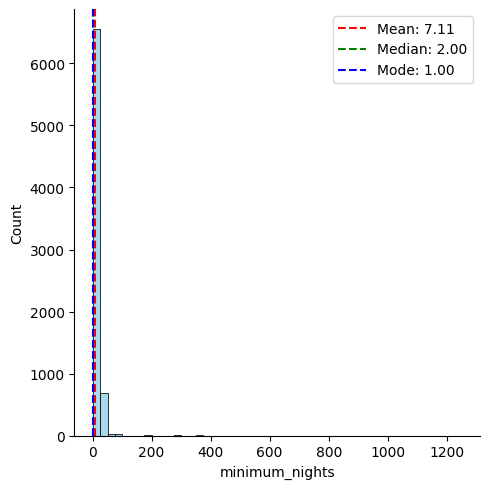

Minimum Nights - Mean: 7.11, Median: 2.00, Mode: 1.00, Max: 1250


In [ ]:
# minimum_nights         0
# amenity_score          0
# number_of_reviews      0
# availability_365       0
# price_class            0

print(f'minimum_nights skewness score: {df["minimum_nights"].skew()}')
print(f'amenity_score skewness score: {df["amenity_score"].skew()}')
print(f'number_of_reviews skewness score: {df["number_of_reviews"].skew()}')
print(f'availability_365 skewness score: {df["availability_365"].skew()}')

# Stats for min nights
plot_feature_distribution('minimum_nights')

# number_of_reviews_mean = df['minimum_nights'].mean()
# number_of_reviews_median = df['minimum_nights'].median()
# number_of_reviews_mode = df['minimum_nights'].mode()[0]
# max_minimum_nights = df['minimum_nights'].max()
# plt.figure(figsize=(5,5))
# sns.displot(df['minimum_nights'], bins=50, color='skyblue')
# plt.axvline(number_of_reviews_mean, color='red', linestyle='--', label=f'Mean: {number_of_reviews_mean:.2f}')
# plt.axvline(number_of_reviews_median, color='green', linestyle='--', label=f'Median: {number_of_reviews_median:.2f}')
# plt.axvline(number_of_reviews_mode, color='blue', linestyle='--', label=f'Mode: {number_of_reviews_mode:.2f}')
# plt.legend()
# plt.show()

# print(f'Minimum Nights - Mean: {number_of_reviews_mean:.2f}, Median: {number_of_reviews_median:.2f}, Mode: {number_of_reviews_mode:.2f}, Max: {max_minimum_nights}')

# Stats for amenity




# plt.figure(figsize=(5,5))
# sns.displot(df['number_of_reviews'], kde=True, bins=30)
# plt.show()
# number_of_reviews_mean = df['number_of_reviews'].mean()
# number_of_reviews_median = df['number_of_reviews'].median()
# number_of_reviews_mode = df['number_of_reviews'].mode()[0]

# plt.figure(figsize=(5,5))
# sns.displot(df['availability_365'], kde=True, bins=30)
# plt.show()
# availability_365_mean = df['availability_365'].mean()
# availability_365_median = df['availability_365'].median() 
# availability_365_mode = df['availability_365'].mode()[0]

# plt.figure(figsize=(5,5))
# sns.displot(df['price_class'], kde=True, bins=4)
# plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


min_max = MinMaxScaler()
ranged_features = ['amenity_score', 'availability_365']
df[ranged_features] = min_max.fit_transform(df[ranged_features])

df.describe()


,minimum_nights,amenity_score,number_of_reviews,availability_365,price_class,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
count,7297.000000,7297.000000,7297.000000,7297.000000,7297.000000,7297.000000,7297.00000,7297.000000,7297.000000,7297.000000,7297.000000,7297.000000,7297.000000
mean,7.106756,0.496088,23.540770,0.309607,1.231602,0.022338,0.41195,0.441688,0.116349,0.007674,0.523366,0.453474,0.023160
std,23.871693,0.290399,45.929467,0.359886,0.758775,0.147790,0.49222,0.496622,0.320665,0.087273,0.499488,0.497865,0.150422
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.240449,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.492135,5.000000,0.126027,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,5.000000,0.751685,23.000000,0.624658,2.000000,0.000000,1.00000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1250.000000,1.000000,629.000000,1.000000,3.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
print(df['price'].isnull().sum())  # 0 missing values
df.dropna(subset=['price'], inplace=True)
print(df['price'].isnull().sum())


: 

In [ ]:
col_with_missing_values = df.isnull().any()
print(col_with_missing_values[col_with_missing_values == True])

: 

In [ ]:
missing_percent = df.isnull().mean() * 100
print(missing_percent[missing_percent > 0])

df['year'] = df.groupby(['make', 'model'])['year'].transform(lambda x: x.fillna(x.median()))
# print(df['year'])

df['car_age'] = 2026 - df['year']
# print(df['car_age'])

df['engine'] = df.groupby(['make', 'model'])['engine'].transform(lambda x: x.fillna(x.median()))
# print(df['engine'])


: 

In [ ]:

df['fuel'] = df['fuel'].fillna(df['fuel'].mode()[0])
df['transmission'] = df['transmission'].fillna(df['transmission'].mode()[0])

cols_to_encode = ['transmission', 'fuel', 'assembly']
ds_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)


: 

In [ ]:
print(f'unique cities: {df["city"].nunique()}') # for year we will use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset
print(f'unique registered: {df["registered"].nunique()}') # for year we will use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset
print(f'unique body: {df["body"].nunique()}') # for body we must use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset
print(f'unique color: {df["color"].nunique()}')  # for color we must use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset
print(f'unique make: {df["make"].nunique()}')  # for make we must use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset
print(f'unique model: {df["model"].nunique()}')  # for make we must use target encoding, since there are several unique values, one hot encoding will create 6 columns, which is too much for our dataset


: 

: 

In [ ]:

# encoding 'registered' column by collapsing rare categories into 'Other'

min_count = 1000
protected = ['Un-Registered']
counts = df['registered'].value_counts()
# print(counts.head(10))

rare_categories = counts[(counts < min_count) & (counts.index.isin(protected)) == False].index
# print(rare_categories)

df['registered_collapsed'] = df['registered'].where(
    df['registered'].isin(rare_categories) == False, 'Other'
)

# print(df['registered_collapsed'].value_counts())

df = pd.get_dummies(df, columns=['registered_collapsed'], prefix='registered', drop_first=True)

# print(ds_encoded.head(5))

: 

In [ ]:

cols_to_encode = ['make', 'model']
target_encoder = TargetEncoder(cols=cols_to_encode, smoothing=10, handle_missing='value', handle_unknown='value')
ds_encoded = target_encoder.fit_transform(ds_encoded, ds_encoded['price'])

print(ds_encoded.head(5))



: 

In [ ]:
X = df.iloc[:, 0:-1].values
y = df.iloc[:, -1].values
print(df.head(5))

: 